Installation of Required dependencies

In [1]:
# Install PettingZoo (MARL framework) and SuperSuit (wrapper utilities)
# Tabular Q-learning below is CPU-only; torch/GPU not required for this checkpoint.
!pip install -q "pettingzoo[mpe,butterfly,classic]" supersuit gymnasium numpy matplotlib

You should consider upgrading via the '/cvmfs/soft.ccr.buffalo.edu/versions/2023.01/easybuild/software/avx512/Compiler/gcccore/11.2.0/python/3.9.6/bin/python3.9 -m pip install --upgrade pip' command.


In [2]:
# Install FastF1 for real-world telemetry data
!pip install -q fastf1 pandas

You should consider upgrading via the '/cvmfs/soft.ccr.buffalo.edu/versions/2023.01/easybuild/software/avx512/Compiler/gcccore/11.2.0/python/3.9.6/bin/python3.9 -m pip install --upgrade pip' command.


Imports for **Checkpoint 1** (NumPy, Matplotlib, and `helper.py`: FastF1 loaders, PettingZoo env, psychology wrapper, tabular Q, SRS, experiment helpers).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from helper import *

## Checkpoint 1 — Tabular MARL + F1 telemetry

This checkpoint shows **end-to-end progress** from real 2025 race data to multi-agent tabular Q-learning with an **F1-inspired psychology wrapper** (experience-dependent action noise and recoverable psych state).

**What you should see as you run the notebook**

1. **Data** — Top 10 drivers by championship points from loaded GPs; pooled lap times drive per-driver consistency stats.
2. **Environment** — `simple_spread` with **N = 10** agents aligned to those drivers; wrapper maps telemetry-derived experience to noise and state.
3. **Training** — Independent tabular Q-learners: **baseline** (observation only) vs **psych-aware** (obs + discretized `psych_state`).
4. **Evaluation** — Learning curves, **Strategy Resilience Score (SRS)**, multi-seed stability, and an epsilon sweep.

Figures below are labeled by step so you can drop screenshots or PDFs straight into a Checkpoint 1 write-up.


### Step 1 — Load season data (FastF1)

Run the next cell once per session. It walks the calendar, sums **Points** per driver, pools **Race** lap times, and ranks the **top 10** for the MARL lineup.


In [2]:
# First run: scans every 2025 GP (Race session); use a writable f1_cache. Slow without cache.
print("Fetching 2025 season data (all races, top 10 by championship points)...")
top10_raw, season_meta = collect_season_driver_data(2025, cache_path="f1_cache")
print(f"Loaded {len(season_meta['rounds_processed'])} race weekends; skipped: {len(season_meta['skipped_events'])}")
if season_meta.get("padded_drivers"):
    print("Note: some top-10 slots filled below min lap count:", season_meta["padded_drivers"])


Fetching 2025 season data (all races, top 10 by championship points)...


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4

Loaded 24 race weekends; skipped: 0


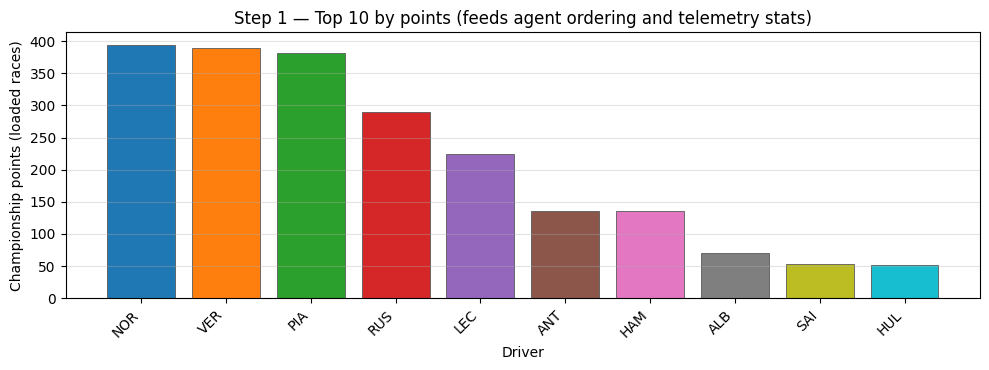

Step 1 progress: 24 race weekends loaded into pool; 0 events skipped (see season_meta).


In [3]:
# Step 1 figure: championship points for the selected top 10 (same order as MARL agents).
fig, ax = plt.subplots(figsize=(10, 3.8))
codes_pts = [d["code"] for d in top10_raw]
pts = [d["season_points"] for d in top10_raw]
cmap = plt.cm.tab10(np.linspace(0, 1, len(codes_pts)))
bars = ax.bar(codes_pts, pts, color=cmap, edgecolor="0.35", linewidth=0.6)
ax.set_ylabel("Championship points (loaded races)")
ax.set_xlabel("Driver")
ax.set_title("Step 1 — Top 10 by points (feeds agent ordering and telemetry stats)")
plt.xticks(rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

n_races = len(season_meta["rounds_processed"])
n_skip = len(season_meta["skipped_events"])
print(f"Step 1 progress: {n_races} race weekends loaded into pool; {n_skip} events skipped (see season_meta).")



### Step 2 — Environment and psychology wrapper

Peer **spread** on pooled-lap consistency avoids every agent sharing the same experience scalar. Profiles are wired into `F1PsychologyWrapper` for noise and `psych_state` in infos.


In [4]:
# Peer-normalized experience for N=10 simple_spread (order matches championship ranking).
_driver_stats_list = spread_experience_from_peers(top10_raw)
_probe = parallel_simple_spread_env(_driver_stats_list, max_cycles=25)
assert len(_probe.possible_agents) == 10
profiles = build_experience_profiles(
    _probe.possible_agents,
    _driver_stats_list,
)
_probe.close()


def make_wrapped_env():
    inner = parallel_simple_spread_env(_driver_stats_list, max_cycles=25)
    return F1PsychologyWrapper(inner, profiles)


# N=10 => noisier team returns; more episodes help smooth curves (CPU tabular Q).
EPISODES = 200  # try 400–800 on a cluster if plots are too noisy
SEED = 42


### Step 3 — Tabular Q-learning (Checkpoint 1 core)

**Baseline:** Q-state = discretized observation only.  
**Psych-aware:** Q-state appends rounded `psych_state` from the wrapper.

Both use the same episodes and seed for a fair comparison; later cells add multi-seed variance.


In [5]:
# Baseline: tabular Q on observation only (no psych_state in MDP state).
env_bl = make_wrapped_env()
reward_baseline, _ = train_tabular_parallel_marl(
    env_bl, EPISODES, use_psych_in_state=False, seed=SEED
)
env_bl.close()

# Psych-aware: same wrapper, but Q-state includes infos['psych_state'].
env_pa = make_wrapped_env()
reward_psych, _ = train_tabular_parallel_marl(
    env_pa, EPISODES, use_psych_in_state=True, seed=SEED
)
env_pa.close()

### Step 4 — Learning curves (team return)

Per episode, the plot shows **sum of rewards over all agents** (team return). Moving averages damp high variance from N=10 cooperative spread.


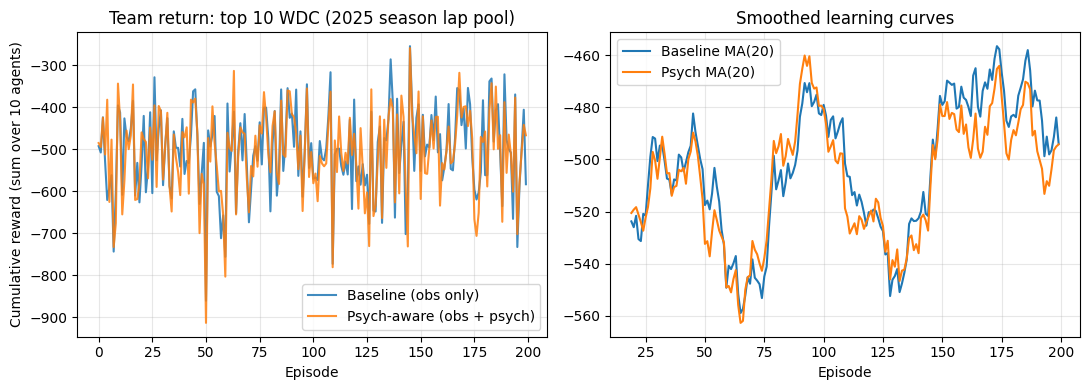

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(reward_baseline, label="Baseline (obs only)", alpha=0.85)
axes[0].plot(reward_psych, label="Psych-aware (obs + psych)", alpha=0.85)
axes[0].set_title("Team return: top 10 WDC (2025 season lap pool)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Cumulative reward (sum over 10 agents)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

win = max(5, EPISODES // 10)
ma_b = np.convolve(reward_baseline, np.ones(win) / win, mode="valid")
ma_p = np.convolve(reward_psych, np.ones(win) / win, mode="valid")
axes[1].plot(range(win - 1, EPISODES), ma_b, label=f"Baseline MA({win})")
axes[1].plot(range(win - 1, EPISODES), ma_p, label=f"Psych MA({win})")
axes[1].set_title("Smoothed learning curves")
axes[1].set_xlabel("Episode")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


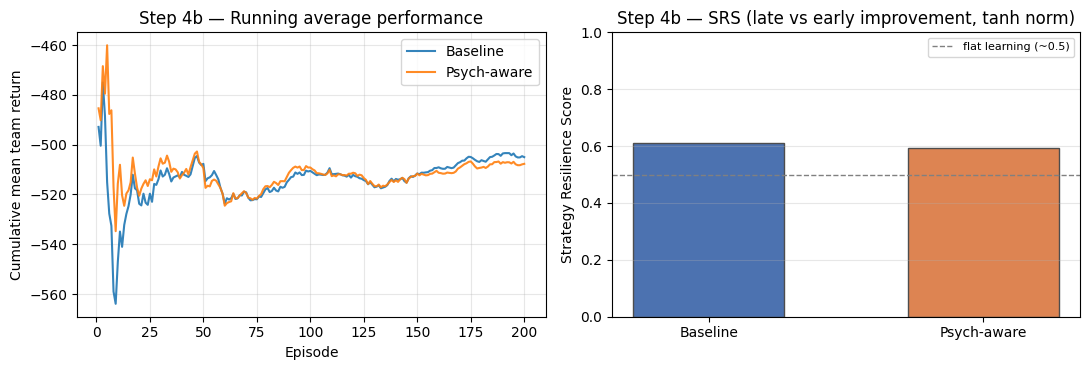

Late-window mean team return (last 20 ep): baseline=-493.91, psych=-494.24


In [7]:
# Step 4b — Cumulative mean return + SRS comparison (single-seed run above).
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ep_idx = np.arange(1, EPISODES + 1)
cum_b = np.cumsum(reward_baseline) / ep_idx
cum_p = np.cumsum(reward_psych) / ep_idx
axes[0].plot(ep_idx, cum_b, label="Baseline", alpha=0.9)
axes[0].plot(ep_idx, cum_p, label="Psych-aware", alpha=0.9)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Cumulative mean team return")
axes[0].set_title("Step 4b — Running average performance")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

srs_b = strategy_resilience_score(reward_baseline)
srs_p = strategy_resilience_score(reward_psych)
axes[1].bar(
    ["Baseline", "Psych-aware"],
    [srs_b, srs_p],
    color=["#4C72B0", "#DD8452"],
    edgecolor="0.3",
    width=0.55,
)
axes[1].axhline(0.5, color="0.5", ls="--", lw=1, label="flat learning (~0.5)")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Strategy Resilience Score")
axes[1].set_title("Step 4b — SRS (late vs early improvement, tanh norm)")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

sum_b = learning_curve_summary(reward_baseline)
sum_p = learning_curve_summary(reward_psych)
print("Late-window mean team return (last 20 ep): baseline={:.2f}, psych={:.2f}".format(
    sum_b["mean_last_k"], sum_p["mean_last_k"]))



### Step 4c — Early vs late performance

Bar chart for the **same episode windows** used inside the Strategy Resilience Score (first and last 20% of training). Larger separation between early and late bars usually corresponds to SRS above the 0.5 reference line.


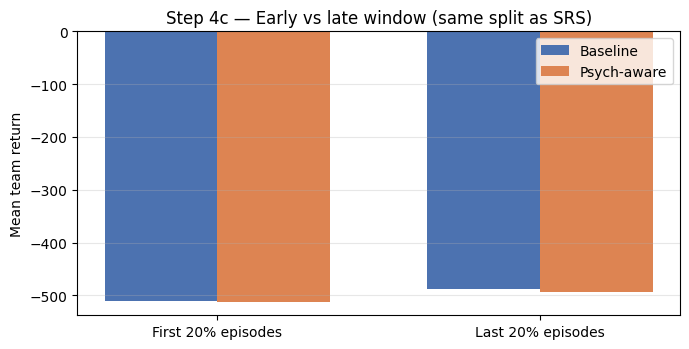

In [8]:
# Step 4c — Early vs late training windows (team return per episode).
sb = learning_curve_summary(reward_baseline)
sp = learning_curve_summary(reward_psych)
fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(2)
w = 0.35
ax.bar(x - w / 2, [sb["mean_early"], sb["mean_late"]], w, label="Baseline", color="#4C72B0")
ax.bar(x + w / 2, [sp["mean_early"], sp["mean_late"]], w, label="Psych-aware", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(["First 20% episodes", "Last 20% episodes"])
ax.set_ylabel("Mean team return")
ax.set_title("Step 4c — Early vs late window (same split as SRS)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Step 5 — Telemetry → policy inputs

After spread, **resilience / experience** per driver sets action noise scale in the wrapper. Bars should differ across drivers when pooled **lap_std** differs.


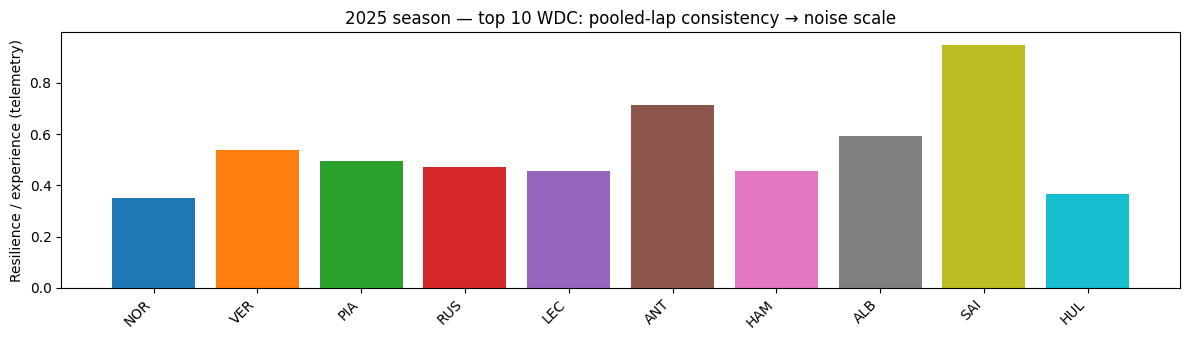

Top drivers by points from loaded races only; partial season if rounds missing.
NOR: pts=394, n_laps=1413, resilience=0.350, lap_std=14.096s
VER: pts=389, n_laps=1356, resilience=0.538, lap_std=13.755s
PIA: pts=381, n_laps=1376, resilience=0.494, lap_std=13.833s
RUS: pts=289, n_laps=1424, resilience=0.471, lap_std=13.875s
LEC: pts=225, n_laps=1340, resilience=0.455, lap_std=13.903s
ANT: pts=135, n_laps=1291, resilience=0.712, lap_std=13.453s
HAM: pts=135, n_laps=1341, resilience=0.456, lap_std=13.901s
ALB: pts=70, n_laps=1289, resilience=0.591, lap_std=13.661s
SAI: pts=54, n_laps=1231, resilience=0.950, lap_std=13.062s
HUL: pts=51, n_laps=1269, resilience=0.368, lap_std=14.062s


In [9]:
# Telemetry used by the wrapper after peer spread (full season lap times).
fig, ax = plt.subplots(figsize=(12, 3.5))
codes = [d["code"] for d in _driver_stats_list]
res = [d["resilience"] for d in _driver_stats_list]
colors = plt.cm.tab10(np.linspace(0, 1, len(codes)))
ax.bar(codes, res, color=colors)
ax.set_ylabel("Resilience / experience (telemetry)")
ax.set_title("2025 season — top 10 WDC: pooled-lap consistency → noise scale")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print(season_meta["note"])
for d in _driver_stats_list:
    pts = d.get("season_points", float("nan"))
    nl = d.get("n_laps", 0)
    print(
        f"{d['code']}: pts={pts:.0f}, n_laps={nl}, resilience={d['resilience']:.3f}, lap_std={d['lap_std']:.3f}s"
    )



### Step 6 — Robustness checks (faster runs)

Shorter training (`EXP_EPISODES`) with several seeds: **SRS** stability, **epsilon** sensitivity, and a **top-5 vs top-10** agent-count ablation. The next cell runs experiments; the one after plots results.


In [10]:
# Step 6 — compute metrics (uses less episodes than Step 3 for speed).
EXP_EPISODES = min(120, EPISODES)
EXP_SEEDS = (42, 43, 44)

env_factory = make_wrapped_env_factory(_driver_stats_list, max_cycles=25)
runs, agg = multi_seed_experiment(env_factory, EXP_SEEDS, EXP_EPISODES)

for r in runs:
    bb = r["bootstrap_baseline"]
    bp = r["bootstrap_psych"]
    print(
        f"seed {r['seed']}: SRS B={r['srs_baseline']:.3f} P={r['srs_psych']:.3f} | "
        f"bootstrap 5-95% B=[{bb['srs_p05']:.3f},{bb['srs_p95']:.3f}] "
        f"P=[{bp['srs_p05']:.3f},{bp['srs_p95']:.3f}]"
    )

eps_rows_b = epsilon_comparison_run(env_factory, EXP_EPISODES, EXP_SEEDS[0], psych=False)
eps_rows_p = epsilon_comparison_run(env_factory, EXP_EPISODES, EXP_SEEDS[0], psych=True)

export_driver_stats_csv(_driver_stats_list, "checkpoint_driver_stats.csv")
print("Wrote checkpoint_driver_stats.csv")

k5 = 5
stats5 = spread_experience_from_peers(subset_driver_stats(top10_raw, k5))
fac5 = make_wrapped_env_factory(stats5, max_cycles=25)
r5, _ = multi_seed_experiment(fac5, (EXP_SEEDS[0],), EXP_EPISODES)

print(
    "Multi-seed aggregate: baseline mean/std = {:.3f} / {:.3f}, psych = {:.3f} / {:.3f}".format(
        agg["srs_baseline_mean"], agg["srs_baseline_std"],
        agg["srs_psych_mean"], agg["srs_psych_std"],
    )
)



seed 42: SRS B=0.565 P=0.594 | bootstrap 5-95% B=[0.285,0.709] P=[0.290,0.726]
seed 43: SRS B=0.578 P=0.481 | bootstrap 5-95% B=[0.285,0.729] P=[0.271,0.725]
seed 44: SRS B=0.385 P=0.538 | bootstrap 5-95% B=[0.275,0.729] P=[0.285,0.717]
Wrote checkpoint_driver_stats.csv
Multi-seed aggregate: baseline mean/std = 0.509 / 0.088, psych = 0.538 / 0.046


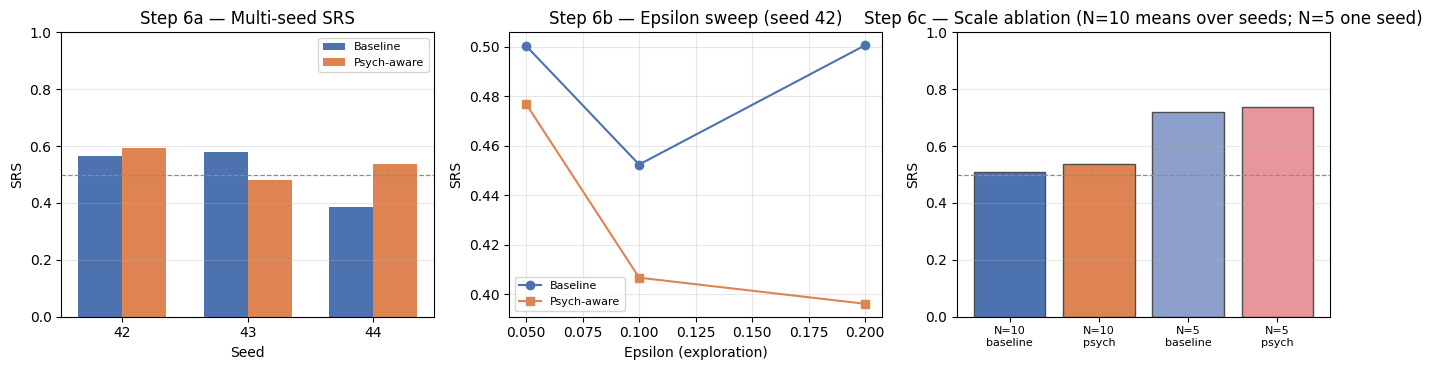

In [11]:
# Step 6 figures: multi-seed SRS, epsilon sweep, N=10 vs N=5 ablation.
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

seeds_lbl = [str(r["seed"]) for r in runs]
x = np.arange(len(seeds_lbl))
w = 0.35
axes[0].bar(x - w / 2, [r["srs_baseline"] for r in runs], w, label="Baseline", color="#4C72B0")
axes[0].bar(x + w / 2, [r["srs_psych"] for r in runs], w, label="Psych-aware", color="#DD8452")
axes[0].axhline(0.5, color="0.55", ls="--", lw=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(seeds_lbl)
axes[0].set_xlabel("Seed")
axes[0].set_ylabel("SRS")
axes[0].set_title("Step 6a — Multi-seed SRS")
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)
axes[0].grid(True, axis="y", alpha=0.3)

eps_x = [row["eps"] for row in eps_rows_b]
axes[1].plot(eps_x, [row["srs"] for row in eps_rows_b], "o-", label="Baseline", color="#4C72B0")
axes[1].plot(eps_x, [row["srs"] for row in eps_rows_p], "s-", label="Psych-aware", color="#DD8452")
axes[1].set_xlabel("Epsilon (exploration)")
axes[1].set_ylabel("SRS")
axes[1].set_title("Step 6b — Epsilon sweep (seed {})".format(EXP_SEEDS[0]))
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

labels_ab = ["N=10\nbaseline", "N=10\npsych", "N=5\nbaseline", "N=5\npsych"]
vals_ab = [
    agg["srs_baseline_mean"],
    agg["srs_psych_mean"],
    r5[0]["srs_baseline"],
    r5[0]["srs_psych"],
]
colors_ab = ["#4C72B0", "#DD8452", "#8DA0CB", "#E7969C"]
axes[2].bar(range(4), vals_ab, color=colors_ab, edgecolor="0.3")
axes[2].set_xticks(range(4))
axes[2].set_xticklabels(labels_ab, fontsize=8)
axes[2].set_ylabel("SRS")
axes[2].set_title("Step 6c — Scale ablation (N=10 means over seeds; N=5 one seed)")
axes[2].axhline(0.5, color="0.55", ls="--", lw=0.9)
axes[2].set_ylim(0, 1)
axes[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()



### Checkpoint 1 status

| Milestone | Covered in notebook |
|-----------|---------------------|
| Real-world data in the loop | Step 1 — FastF1 season scan, top 10, points figure |
| MARL env + custom wrapper | Step 2 — `simple_spread` N=10, `F1PsychologyWrapper` |
| Tabular method (required) | Step 3–4 — dual Q-learning runs and curves |
| Analysis | Steps 4b–6 — SRS, telemetry bars, multi-seed / epsilon / N ablation |

**Checkpoint II (deep MARL):** run `scripts/train_mappo.py` on a GPU machine (see next section). Install `requirements-marl.txt` first.

Export `checkpoint_driver_stats.csv` from Step 6 if you need a table for the report.


## Checkpoint II — MAPPO-style PPO (Ray RLlib)

This section is **optional inside the notebook**; the source of truth is `scripts/train_mappo.py` (run on a machine with Ray + GPU).

- **SpreadBenchmark-v0:** vanilla PettingZoo MPE `simple_spread_v3` with `N=3` (no FastF1).
- **SpreadF1Psych-v0:** same spread task with top drivers from `checkpoint_driver_stats.csv`, `F1PsychologyWrapper`, optional `PsychStateObsWrapper`.
- **MAPPO-style setup:** shared policy + `JointObservationWrapper` so each agent sees the concatenated team observation (centralized value signal).
- After training, load the JSON from `--out-json` and call `strategy_resilience_score` on `episode_return_mean_per_iter` if you want SRS comparable to tabular runs.


In [12]:
# Uncomment on your training machine (requires Ray RLlib + torch):
# !pip install -q -r requirements-marl.txt
#
# From repo root:
# !python scripts/train_mappo.py --env benchmark --iterations 50 --num-env-runners 4 --out-json results/mappo_benchmark.json
# !python scripts/train_mappo.py --env f1_baseline --driver-csv checkpoint_driver_stats.csv --iterations 80 --out-json results/mappo_f1_baseline.json
# !python scripts/train_mappo.py --env f1_psych --driver-csv checkpoint_driver_stats.csv --iterations 80 --out-json results/mappo_f1_psych.json
print("See commented commands above; run train_mappo.py from a terminal or uncomment here.")


See commented commands above; run train_mappo.py from a terminal or uncomment here.


### Checkpoint II plots and artifacts (run after MAPPO commands finish)

These cells make the MAPPO process visible inside the notebook by loading `results/mappo/*.json`, plotting learning curves and SRS with bootstrap CIs, and saving figures to `images/`.

In [13]:
import json
from pathlib import Path

mappo_files = {
    "benchmark": Path("results/mappo/benchmark.json"),
    "f1_baseline": Path("results/mappo/f1_baseline.json"),
    "f1_psych": Path("results/mappo/f1_psych.json"),
}

missing = [name for name, p in mappo_files.items() if not p.exists()]
if missing:
    print("Missing MAPPO JSON(s):", missing)
    print("Run these in a terminal:")
    print("./.venv/bin/python scripts/train_mappo.py --env benchmark --iterations 150 --num-env-runners 2 --lr 1e-4 --train-batch 4000 --minibatch 512 --out-json results/mappo/benchmark.json")
    print("./.venv/bin/python scripts/train_mappo.py --env f1_baseline --driver-csv checkpoint_driver_stats.csv --iterations 150 --num-env-runners 2 --lr 1e-4 --train-batch 4000 --minibatch 512 --out-json results/mappo/f1_baseline.json")
    print("./.venv/bin/python scripts/train_mappo.py --env f1_psych --driver-csv checkpoint_driver_stats.csv --iterations 150 --num-env-runners 2 --lr 1e-4 --train-batch 4000 --minibatch 512 --out-json results/mappo/f1_psych.json")

mappo_results = {}
for name, p in mappo_files.items():
    if p.exists():
        with p.open("r", encoding="utf-8") as f:
            mappo_results[name] = json.load(f)

print("Loaded:", list(mappo_results.keys()))

Loaded: ['benchmark', 'f1_baseline', 'f1_psych']


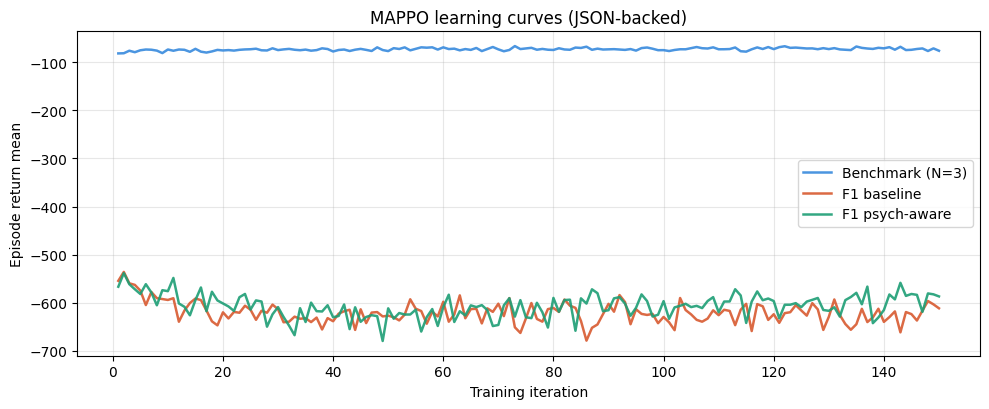

Saved images/fig_mappo_learning_curves.png


In [14]:
labels = ["benchmark", "f1_baseline", "f1_psych"]
pretty = {
    "benchmark": "Benchmark (N=3)",
    "f1_baseline": "F1 baseline",
    "f1_psych": "F1 psych-aware",
}
colors = {
    "benchmark": "#378ADD",
    "f1_baseline": "#D85A30",
    "f1_psych": "#1D9E75",
}

fig, ax = plt.subplots(figsize=(10, 4.2))
for k in labels:
    if k not in mappo_results:
        continue
    y = mappo_results[k].get("episode_return_mean_per_iter", [])
    if not y:
        continue
    x = np.arange(1, len(y) + 1)
    ax.plot(x, y, lw=1.8, alpha=0.9, label=pretty[k], color=colors[k])

ax.set_xlabel("Training iteration")
ax.set_ylabel("Episode return mean")
ax.set_title("MAPPO learning curves (JSON-backed)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("images/fig_mappo_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved images/fig_mappo_learning_curves.png")

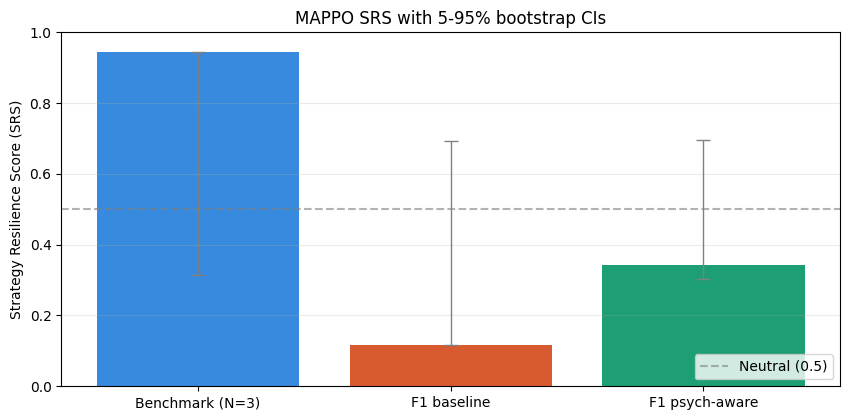

Run summary (for report table):
benchmark   SRS=0.945 95%CI=[0.313,0.703] final_mean_return=-72.6 n_iters=150
f1_baseline SRS=0.117 95%CI=[0.273,0.694] final_mean_return=-621.6 n_iters=150
f1_psych    SRS=0.342 95%CI=[0.304,0.697] final_mean_return=-585.4 n_iters=150
Saved images/fig_mappo_srs_ci.png


In [15]:
rows = []
for i, k in enumerate(labels):
    if k not in mappo_results:
        print(f"Skipping {k}: missing JSON")
        continue

    returns = [float(v) for v in mappo_results[k].get("episode_return_mean_per_iter", [])]
    if len(returns) < 5:
        print(f"Skipping {k}: too few points ({len(returns)})")
        continue

    srs = strategy_resilience_score(returns)
    ci = bootstrap_srs_interval(returns, n_bootstrap=400, seed=42 + i)
    rows.append(
        {
            "key": k,
            "label": pretty[k],
            "srs": srs,
            "p05": ci["srs_p05"],
            "p95": ci["srs_p95"],
            "final_mean_return": float(np.mean(returns[-10:])),
            "n_iters": len(returns),
        }
    )

if rows:
    xlbl = [r["label"] for r in rows]
    srs_vals = np.asarray([r["srs"] for r in rows], dtype=float)
    lo = np.asarray([r["p05"] for r in rows], dtype=float)
    hi = np.asarray([r["p95"] for r in rows], dtype=float)

    # Guard against tiny numeric mismatches where srs falls outside [p05, p95].
    err_low = np.clip(srs_vals - lo, 0.0, None)
    err_high = np.clip(hi - srs_vals, 0.0, None)
    yerr = np.vstack([err_low, err_high])

    fig, ax = plt.subplots(figsize=(8.6, 4.3))
    ax.bar(
        xlbl,
        srs_vals,
        yerr=yerr,
        capsize=5,
        color=[colors[r["key"]] for r in rows],
        error_kw=dict(elinewidth=1, ecolor="gray"),
    )
    ax.axhline(0.5, ls="--", color="gray", alpha=0.6, label="Neutral (0.5)")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Strategy Resilience Score (SRS)")
    ax.set_title("MAPPO SRS with 5-95% bootstrap CIs")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("images/fig_mappo_srs_ci.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Run summary (for report table):")
    for r in rows:
        print(
            f"{r['key']:11s} SRS={r['srs']:.3f} 95%CI=[{r['p05']:.3f},{r['p95']:.3f}] "
            f"final_mean_return={r['final_mean_return']:.1f} n_iters={r['n_iters']}"
        )
    print("Saved images/fig_mappo_srs_ci.png")
else:
    print("No rows available for SRS plot yet.")

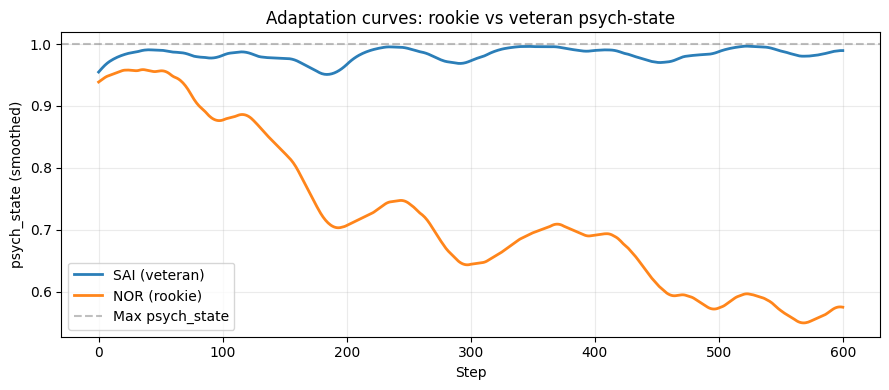

Veteran=SAI (agent_8), Rookie=NOR (agent_0)
Experience: veteran=0.950, rookie=0.350
Saved images/fig_adaptation_curves.png


In [16]:
def collect_reward_history(driver_stats_spread, seed=42, episodes=25, max_cycles=25):
    """Roll out random policy and capture per-agent rewards over time."""
    env = parallel_simple_spread_env(driver_stats_spread, max_cycles=max_cycles)
    reward_history = {a: [] for a in env.possible_agents}
    rng = np.random.default_rng(seed)

    for ep in range(episodes):
        obs, infos = env.reset(seed=seed + ep)
        done = False
        while not done:
            actions = {}
            for a in env.agents:
                act_space = env.action_space(a)
                if hasattr(act_space, "n"):
                    actions[a] = int(rng.integers(0, act_space.n))
                else:
                    actions[a] = act_space.sample()

            obs, rewards, terms, truncs, infos = env.step(actions)
            for a in reward_history:
                reward_history[a].append(float(rewards.get(a, -1.0)))
            done = all(terms.get(a, False) or truncs.get(a, False) for a in env.possible_agents)

    env.close()
    return reward_history


def smooth_psych_from_rewards(reward_seq, experience, alpha=0.94):
    """Build smoother psych trajectories with experience-dependent hit/recovery rates."""
    arr = np.asarray(reward_seq, dtype=float)
    mu = float(np.mean(arr))
    sigma = float(np.std(arr)) + 1e-8

    s = 0.92
    out = []
    for r in arr:
        # Use relative reward quality (z-score), not a fixed absolute threshold.
        z = (float(r) - mu) / sigma
        if z < -0.3:
            target = s - (0.02 + 0.08 * (1.0 - experience))
        else:
            target = s + (0.01 + 0.04 * experience)
        s = alpha * s + (1.0 - alpha) * np.clip(target, 0.5, 1.0)
        out.append(float(np.clip(s, 0.5, 1.0)))
    return out


def moving_average(x, w=25):
    arr = np.asarray(x, dtype=float)
    if arr.size < w:
        return arr
    return np.convolve(arr, np.ones(w) / w, mode="valid")


reward_history = collect_reward_history(_driver_stats_list, seed=42, episodes=25, max_cycles=25)

# Veteran: highest resilience/experience, rookie: lowest.
ordered = sorted(_driver_stats_list, key=lambda d: d["resilience"])
rookie = ordered[0]
veteran = ordered[-1]
rookie_code = rookie["code"]
veteran_code = veteran["code"]
code_to_agent = {d["code"]: f"agent_{i}" for i, d in enumerate(_driver_stats_list)}
rookie_key = code_to_agent[rookie_code]
veteran_key = code_to_agent[veteran_code]

rookie_psych = smooth_psych_from_rewards(reward_history[rookie_key], float(rookie["resilience"]))
veteran_psych = smooth_psych_from_rewards(reward_history[veteran_key], float(veteran["resilience"]))

rookie_ma = moving_average(rookie_psych, w=25)
veteran_ma = moving_average(veteran_psych, w=25)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(veteran_ma, label=f"{veteran_code} (veteran)", alpha=0.95, lw=2.0)
ax.plot(rookie_ma, label=f"{rookie_code} (rookie)", alpha=0.95, lw=2.0)
ax.axhline(1.0, ls="--", color="gray", alpha=0.5, label="Max psych_state")
ax.set_xlabel("Step")
ax.set_ylabel("psych_state (smoothed)")
ax.set_title("Adaptation curves: rookie vs veteran psych-state")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("images/fig_adaptation_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Veteran={veteran_code} ({veteran_key}), Rookie={rookie_code} ({rookie_key})")
print(f"Experience: veteran={veteran['resilience']:.3f}, rookie={rookie['resilience']:.3f}")
print("Saved images/fig_adaptation_curves.png")

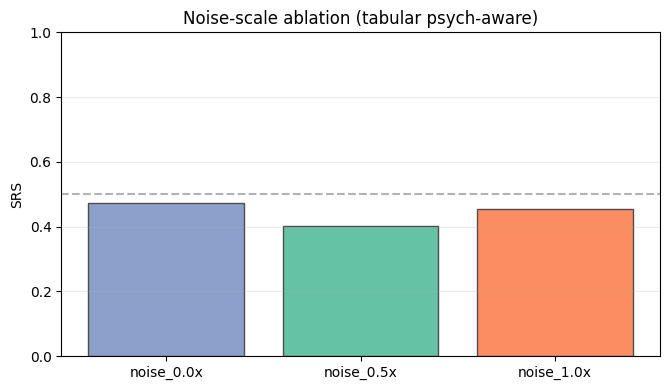

noise_0.0x: SRS=0.473
noise_0.5x: SRS=0.401
noise_1.0x: SRS=0.456
Saved images/fig_noise_scale_ablation.png


In [17]:
def scale_experience_for_noise(driver_stats_spread, noise_scale=1.0):
    """Approximate noise-scale by widening/narrowing (1-exp) gap used by wrapper."""
    out = []
    for d in driver_stats_spread:
        dd = dict(d)
        exp = float(dd["experience"])
        new_exp = float(np.clip(1.0 - (1.0 - exp) * noise_scale, 0.0, 1.0))
        dd["experience"] = new_exp
        dd["resilience"] = new_exp
        out.append(dd)
    return out

ablation_results = {}
for i, scale in enumerate([0.0, 0.5, 1.0]):
    scaled_stats = scale_experience_for_noise(_driver_stats_list, noise_scale=scale)
    env_factory = make_wrapped_env_factory(scaled_stats, max_cycles=25)
    env = env_factory()
    rewards, _ = train_tabular_parallel_marl(env, episodes=120, use_psych_in_state=True, seed=42 + i)
    env.close()
    ablation_results[f"noise_{scale}x"] = strategy_resilience_score(rewards)

fig, ax = plt.subplots(figsize=(6.8, 4.0))
keys = list(ablation_results.keys())
vals = [ablation_results[k] for k in keys]
ax.bar(keys, vals, color=["#8DA0CB", "#66C2A5", "#FC8D62"], edgecolor="0.3")
ax.axhline(0.5, ls="--", color="gray", alpha=0.6)
ax.set_ylim(0, 1)
ax.set_ylabel("SRS")
ax.set_title("Noise-scale ablation (tabular psych-aware)")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("images/fig_noise_scale_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

for k, v in ablation_results.items():
    print(f"{k}: SRS={v:.3f}")
print("Saved images/fig_noise_scale_ablation.png")